# Transform and Select

In [1]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import pandas as pd

from episode_functions import *
from gd1 import GD1Koposov10
from reflex import reflex_correct

Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
filename = 'data/gd1_data.hdf'
centerline_df = pd.read_hdf(filename, 'centerline_df')
selected_df = pd.read_hdf(filename, 'selected_df')

In [3]:
pm1_min = -8.9
pm1_max = -6.9
pm2_min = -2.2
pm2_max =  1.0

pm1_rect, pm2_rect = make_rectangle(
    pm1_min, pm1_max, pm2_min, pm2_max)
gd1_frame = GD1Koposov10()

## Selecting by proper motion

Review:
* identified a region near GD-1
* transformed to ICRS
* selected stars physically near GD-1
* transformed back to GD-1
* identified a pure same around the centerline of GD-1
* found the anomolous proper motion associated with GD-1
* applied proper motion to larger GD-1 sample to identify stars in stream

This process took us from 100,000 stars to ~1000 stars

* Better to do this in ADQL rather than download all 100,000 stars. 
* Need proper motion in ICRS

### Check proper motion in GD-1 frame

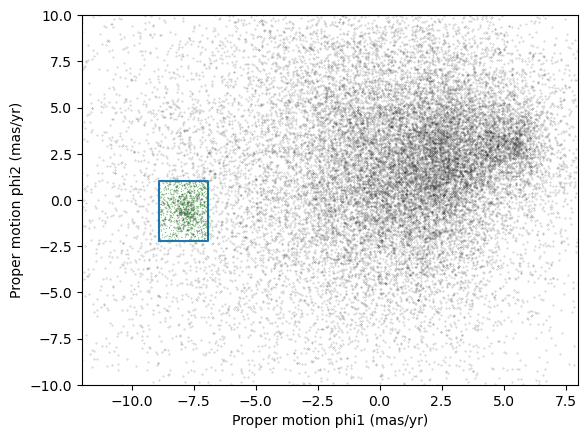

In [5]:
plot_proper_motion(centerline_df)

plt.plot(pm1_rect, pm2_rect)

x = selected_df['pm_phi1']
y = selected_df['pm_phi2']
plt.plot(x, y, 'gx', markersize=0.3, alpha=0.3);

### Plot in ICRS frame with `pmra` and `pmdec` columns

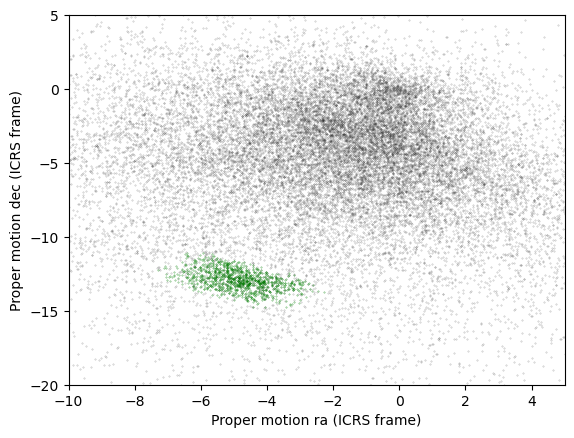

In [6]:
x = centerline_df['pmra']
y = centerline_df['pmdec']
plt.plot(x, y, 'ko', markersize=0.3, alpha=0.3)

x = selected_df['pmra']
y = selected_df['pmdec']
plt.plot(x, y, 'gx', markersize=1, alpha=0.3)
    
plt.xlabel('Proper motion ra (ICRS frame)')
plt.ylabel('Proper motion dec (ICRS frame)')

plt.xlim([-10, 5])
plt.ylim([-20, 5]);

### EXERCISE (5 MINUTES)
Looking at the proper motion of the stars we identified along the centerline of GD-1, in the ICRS reference frame define a rectangle (pmra_min, pmra_max, pmdec_min, and pmdec_max) that encompass the proper motion of the majority of the stars near the centerline of GD-1 without including too much contamination from other stars.

### Solution

In [4]:
pmra_min = -6.70
pmra_max = -3
pmdec_min = -14.31
pmdec_max = -11.2

## Assembling the query

Recall from yesterday our spatial selection query

In [9]:
candidate_coord_query_base = """SELECT
{columns}
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON({sky_point_list}))
"""

No that we prototyped our proper motion filter:
* expand physical region
* add proper motion filter to SQL query

In [5]:
phi1_min = -70 * u.degree
phi1_max = -20 * u.degree
phi2_min = -5 * u.degree
phi2_max = 5 * u.degree

create x and y coordinates of rectangle

In [6]:
phi1_rect, phi2_rect = make_rectangle(
    phi1_min, phi1_max, phi2_min, phi2_max)

tranform to icrs

In [7]:
corners = SkyCoord(phi1 = phi1_rect,
                   phi2=phi2_rect,
                   frame=gd1_frame)
corners_icrs = corners.transform_to('icrs')

use our function `skycoord_to_string` to convert this into the input for ADQL

In [8]:
sky_point_list = skycoord_to_string(corners_icrs)
sky_point_list

'135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862'

Define columns we want to select

In [15]:
columns = 'source_id, ra, dec, pmra, pmdec'

### DO NOT RUN THIS QUERY WE NEED TO ADD PROPER MOTION FILTER

name variable candidates since these are our GD1 candidate stars`

In [16]:
#DO NOT RUN THIS QUERY WE NEED TO ADD PROPER MOTION FILTER
candidate_coord_query = candidate_coord_query_base.format(columns=columns, 
                            sky_point_list=sky_point_list)
print(candidate_coord_query)

SELECT
source_id, ra, dec, pmra, pmdec
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON(135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862))



## Selecting proper motion

# EXERCISE (10 MINUTES)
Define candidate_coord_pm_query_base, starting with candidate_coord_query_base and adding two new BETWEEN clauses to select stars whose coordinates of proper motion, pmra and pmdec, fall within the region defined by pmra_min, pmra_max, pmdec_min, and pmdec_max. In the next exercise we will use the format statement to fill in the values we defined above.

In [17]:
candidate_coord_pm_query_base = """SELECT 
{columns}
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON({sky_point_list}))
  AND pmra BETWEEN {pmra_min} AND  {pmra_max}
  AND pmdec BETWEEN {pmdec_min} AND {pmdec_max}
"""

# EXERCISE (5 MINUTES)
Use format to format candidate_coord_pm_query_base and define candidate_coord_pm_query, filling in the values of columns, sky_point_list, and pmra_min, pmra_max, pmdec_min, pmdec_max.

In [18]:
candidate_coord_pm_query = candidate_coord_pm_query_base.format(columns=columns, 
                            sky_point_list=sky_point_list,
                            pmra_min=pmra_min,
                            pmra_max=pmra_max,
                            pmdec_min=pmdec_min,
                            pmdec_max=pmdec_max)
print(candidate_coord_pm_query)

SELECT 
source_id, ra, dec, pmra, pmdec
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON(135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862))
  AND pmra BETWEEN -6.7 AND  -3
  AND pmdec BETWEEN -14.31 AND -11.2



In [26]:
%timeit
candidate_coord_pm_job = Gaia.launch_job_async(candidate_coord_pm_query)
print(candidate_coord_pm_job)

INFO: Query finished. [astroquery.utils.tap.core]
<Table length=8409>
   name    dtype    unit                              description                            
--------- ------- -------- ------------------------------------------------------------------
source_id   int64          Unique source identifier (unique within a particular Data Release)
       ra float64      deg                                                    Right ascension
      dec float64      deg                                                        Declination
     pmra float64 mas / yr                         Proper motion in right ascension direction
    pmdec float64 mas / yr                             Proper motion in declination direction
Jobid: 591ccd8e-e918-11f0-a3b5-bc97e148b76b-O
Phase: COMPLETED
Owner: None
Output file: async_20260104025203.vot
Results: None


In [27]:
candidate_gaia_table = candidate_coord_pm_job.get_results()
len(candidate_gaia_table)

8409

### Call out: 
why didn't we use POLYGON? ADQL only wants POLYGON to be used on coordinates

`sky_point_list`, `pmra_min`, `pmra_max`, `pmdec_min`, `pmdec_max` are all important parts of our database selection - we should save for reproducibility later

Put in a pandas object to save to HDF5

We are going to build a series ( we don't need the full data frame since we don't have tabular data)

In [29]:
d = dict(sky_point_list=sky_point_list, 
         pmra_min=pmra_min, 
         pmra_max=pmra_max, 
         pmdec_min=pmdec_min, 
         pmdec_max=pmdec_max)
d

{'sky_point_list': '135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862',
 'pmra_min': -6.7,
 'pmra_max': -3,
 'pmdec_min': -14.31,
 'pmdec_max': -11.2}

In [30]:
point_series = pd.Series(d)
point_series

sky_point_list    135.306, 8.39862, 126.51, 13.4449, 163.017, 54...
pmra_min                                                       -6.7
pmra_max                                                         -3
pmdec_min                                                    -14.31
pmdec_max                                                     -11.2
dtype: object

In [31]:
filename = 'gd1_data.hdf'
point_series.to_hdf(filename, key='point_series')

/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_17268/290492992.py:2: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  point_series.to_hdf(filename, key='point_series')


Warning: because we're mixing types. We don't really care about this - our data is small

## Plot one more time

What did we retrieve from the Gaia database?

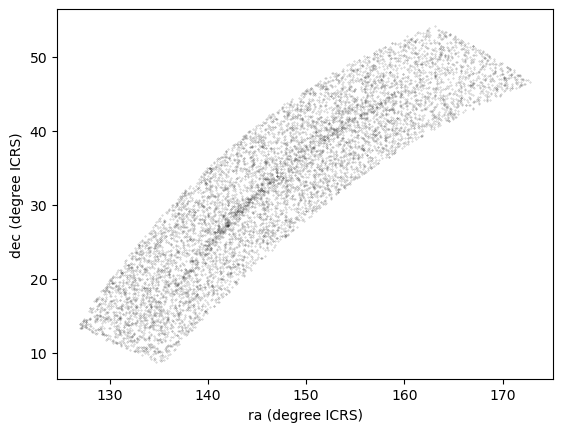

In [32]:
x = candidate_gaia_table['ra']
y = candidate_gaia_table['dec']
plt.plot(x, y, 'ko', markersize=0.3, alpha=0.3)

plt.xlabel('ra (degree ICRS)')
plt.ylabel('dec (degree ICRS)');

Note: we identified our proper motion selection criteria in the GD1 frame because it was easier to select a pure (centerline) sample of stars in that frame

Transform back to GD-1 using our function

In [33]:
candidate_gaia_df = make_dataframe(candidate_gaia_table)

check results using our function! All of that work is paying off

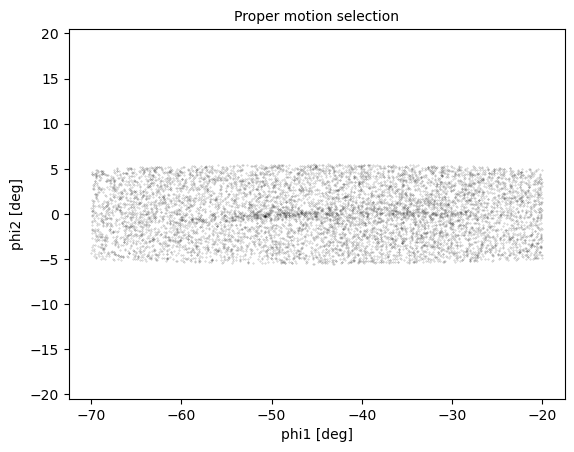

In [34]:
plot_pm_selection(candidate_gaia_df)

Comparible to first panel of figure in paper

## Summary

* Search the same region and download less data, or
* Search a larger region while still downloading a manageable amount of data.
* When possible, ‘move the computation to the data’; that is, do as much of the work as possible on the database server before downloading the data.

# Join

Use panstarrs to select stars all of the same age to get even more pure GD1 sample

To make our selection we need proper motions from Gaia and g and i band magnitudes from PanSTARRS. Gaia has done the hard work of cross-matching the two databases, but the information is spread across multiple tables. Gaia does this by doing a cone search and then additionally matching color and brightness

If you have to cross-match on your own - astropy provides some tools. 

## The best neighbour table

Each star we identified in our Gaia data base has a source_id from Gaia. We need to find the corresponding obj_id in the PanSTARRS database. The best neighbours table has this mapping. So we will take the stars we identified in the `gaia_source` table and find them in the `panstarrs1_best_neighbour` table by matching the `source_id` column. Then we will use the `obj_id` column from the `panstarrs1_best_neighbour` to find the g and i band magnitudes of these stars in the `panstarrs1_original_valid` table by matching the `original_ext_source_id` to the `obj_id` . 

Use JOIN to tell SQL how to connect tables

What's in the best neighbours table?

In [35]:
ps_best_neighbour_meta = Gaia.load_table('gaiadr2.panstarrs1_best_neighbour')

In [36]:
print(ps_best_neighbour_meta)

TAP Table name: gaiadr2.panstarrs1_best_neighbour
Description: Pan-STARRS1 BestNeighbour table lists each matched Gaia object with its
best neighbour in the external catalogue.
There are 1 327 157 objects in the filtered version of Pan-STARRS1 used
to compute this cross-match that have too early epochMean.
Size (bytes): 98462015488
Num. columns: 7


Get the columns

In [37]:
for column in ps_best_neighbour_meta.columns:
    print(column.name)

source_id
original_ext_source_id
angular_distance
number_of_neighbours
number_of_mates
best_neighbour_multiplicity
gaia_astrometric_params


#### Columns we care about:
`source_id`, which we will match up with source_id in the Gaia table.

`best_neighbour_multiplicity`, which indicates how many sources in Pan-STARRS are matched with the same probability to this source in Gaia (should be 1)

`number_of_mates`, which indicates the number of other sources in Gaia that are matched with the same source in Pan-STARRS (should be 0)

`original_ext_source_id`, which we will match up with obj_id in the Pan-STARRS table.

We don't care about:
`number_of_neighbours` which is the number of stars in Pan-STARRS that match in terms of position, before using other criteria to choose the most likely match. 

Let's use TOP 5 to check out explore this table further

In [38]:
ps_best_neighbour_query = """SELECT 
TOP 5
source_id, best_neighbour_multiplicity, number_of_mates, original_ext_source_id
FROM gaiadr2.panstarrs1_best_neighbour
"""

In [39]:
ps_best_neighbour_job = Gaia.launch_job(ps_best_neighbour_query)

In [40]:
ps_best_neighbour_results = ps_best_neighbour_job.get_results()
ps_best_neighbour_results

source_id,best_neighbour_multiplicity,number_of_mates,original_ext_source_id
int64,int16,int16,int64
6784400267124450304,1,0,69743200885011198
5634067974964266368,1,0,69741383006331141
5630599114562888064,1,0,69741421972031215
6207054992082228224,1,0,69742321460291252
6745938968138399360,1,0,69742925693841271


## The Pan-STARRS Table

Know `obj_id` so we can find PanSTARRS photometry

Get the meta data

In [41]:
ps_valid_meta = Gaia.load_table('gaiadr2.panstarrs1_original_valid')

In [42]:
print(ps_valid_meta)

TAP Table name: gaiadr2.panstarrs1_original_valid
Description: The Panoramic Survey Telescope and Rapid Response System (Pan-STARRS) is
a system for wide-field astronomical imaging developed and operated by
the Institute for Astronomy at the University of Hawaii. Pan-STARRS1
(PS1) is the first part of Pan-STARRS to be completed and is the basis
for Data Release 1 (DR1). The PS1 survey used a 1.8 meter telescope and
its 1.4 Gigapixel camera to image the sky in five broadband filters (g,
r, i, z, y).

The current table contains a filtered subsample of the 10 723 304 629
entries listed in the original ObjectThin table.
We used only ObjectThin and MeanObject tables to extract
panstarrs1OriginalValid table, this means that objects detected only in
stack images are not included here. The main reason for us to avoid the
use of objects detected in stack images is that their astrometry is not
as good as the mean objects astrometry: “The stack positions (raStack,
decStack) have considerably larg

Look at the columns

In [43]:
for column in ps_valid_meta.columns:
    print(column.name)

obj_name
obj_id
ra
dec
ra_error
dec_error
epoch_mean
g_mean_psf_mag
g_mean_psf_mag_error
g_flags
r_mean_psf_mag
r_mean_psf_mag_error
r_flags
i_mean_psf_mag
i_mean_psf_mag_error
i_flags
z_mean_psf_mag
z_mean_psf_mag_error
z_flags
y_mean_psf_mag
y_mean_psf_mag_error
y_flags
n_detections
zone_id
obj_info_flag
quality_flag


The ones we will use are:

`obj_id`, which we will match up with original_ext_source_id in the best neighbor table.

`g_mean_psf_mag`, which contains mean magnitude from the g filter.

`i_mean_psf_mag`, which contains mean magnitude from the i filter.

Let's use TOP 5 to investigate this table

In [44]:
ps_valid_query = """SELECT 
TOP 5
obj_id, g_mean_psf_mag, i_mean_psf_mag 
FROM gaiadr2.panstarrs1_original_valid
"""

In [45]:
ps_valid_job = Gaia.launch_job(ps_valid_query)

In [46]:
ps_valid_results = ps_valid_job.get_results()
ps_valid_results

obj_id,g_mean_psf_mag,i_mean_psf_mag
,,mag
int64,float64,float64
67552250229077933,--,21.869499206543
67133353844641418,--,19.9967002868652
67552265433997719,--,21.3826007843018
67130208282521431,--,20.953800201416
67132633294031385,20.7784004211426,--


## Joining tables

### Show figures

This is going to be complex so start with simple and build complexity

Start with the TOP 10 results for one column in a cone search

In [47]:
test_cone_query = """SELECT 
TOP 10 
source_id
FROM gaiadr2.gaia_source
WHERE 1=CONTAINS(
  POINT(ra, dec),
  CIRCLE(88.8, 7.4, 0.08333333))
"""

In [48]:
test_cone_job = Gaia.launch_job(test_cone_query)

In [49]:
test_cone_results = test_cone_job.get_results()
test_cone_results

source_id
int64
3322774068134271104
3322773724537891456
3322774102495010432
3322773758896635392
3322776164078251264
3322774549171570432
3322774480452095104
3322774617890035968
3322773930695337344


remove top 10 and add more columns

In [50]:
cone_base_query = """SELECT 
{columns}
FROM gaiadr2.gaia_source
WHERE 1=CONTAINS(
  POINT(ra, dec),
  CIRCLE(88.8, 7.4, 0.08333333))
"""

Check that everything looks right before we run it

In [51]:
columns = 'source_id, ra, dec, pmra, pmdec'

cone_query = cone_base_query.format(columns=columns)
print(cone_query)

SELECT 
source_id, ra, dec, pmra, pmdec
FROM gaiadr2.gaia_source
WHERE 1=CONTAINS(
  POINT(ra, dec),
  CIRCLE(88.8, 7.4, 0.08333333))



In [52]:
cone_job = Gaia.launch_job(cone_query)

In [53]:
cone_results = cone_job.get_results()
cone_results

source_id,ra,dec,pmra,pmdec
,deg,deg,mas / yr,mas / yr
int64,float64,float64,float64,float64
3322773758899157120,88.83227057144585,7.325577341429926,--,--
3322774102494018816,88.80206135956955,7.352773486341117,-0.44875204757926507,0.06388813412223136
3322774480453644544,88.84518455090614,7.369528614293598,1.0487255252218055,-3.2216341675741775
3322773827617101824,88.82682026502691,7.325482750557392,0.12930793961994053,-1.3969640073614107
3322774068137235840,88.83061405130354,7.345969809553393,0.2004557581720638,-1.9310389729694923
3322774205573198720,88.86471759263127,7.350048288745576,-2.177800084152019,-8.832994968942021
3322776164079777664,88.86819599697338,7.41377228713048,--,--
3322773965055082240,88.78952120642428,7.331482411015145,0.4787821978718813,0.1871980156380569


# Digression: Table optimization

SQL is good with large databases but it is not trivial to connect large tables to large tables and there is optimization that you can do to make things run faster. In optimizing for Gaia DR4, they inadvertantly broke the optimization for JOIN with ADQL CONTAINS

So - we are going to run the CONTAINS query on the Gaia table and save the results. We will then upload the table to the Gaia server and use it to get all of the information from the other tables

Step 1: save the `gaia_source` results as a vo table. This is an xml file (looks a lot like html) universal format for virtual observatories

In [55]:
cone_results.write('cone_results.vo', format='votable', overwrite=True)

step 2: log into your Gaia account

In [56]:
Gaia.login()

INFO: Login to gaia TAP server [astroquery.gaia.core]


User:  kbostroe
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


step 3: upload (note you can only do this one)

In [64]:
upload_job = Gaia.upload_table(upload_resource='cone_results.vo', table_name='cone_results_gaia',
                               table_description='cone search results from gaiadr2.gaia_source table')

INFO: Sending file: cone_results.vo [astroquery.utils.tap.core]
500 Error 500:
java.lang.IllegalStateException: Can't overwrite cause with uk.ac.starlink.table.TableFormatException: Can not execute the following SQL: 
CREATE TABLE user_kbostroe.cone_results_gaia ( "source_id" bigint, "ra" double precision, "dec" double precision, "pmra" double precision, "pmdec" double precision,  cone_results_gaia_oid SERIAL )  DISTRIBUTED BY (cone_results_gaia_oid)
Because: ERROR: relation "cone_results_gaia" already exists


HTTPError: Error 500:
java.lang.IllegalStateException: Can't overwrite cause with uk.ac.starlink.table.TableFormatException: Can not execute the following SQL: 
CREATE TABLE user_kbostroe.cone_results_gaia ( "source_id" bigint, "ra" double precision, "dec" double precision, "pmra" double precision, "pmdec" double precision,  cone_results_gaia_oid SERIAL )  DISTRIBUTED BY (cone_results_gaia_oid)
Because: ERROR: relation "cone_results_gaia" already exists

Step 4: assign reference to universal variable `user_<username>.<table_name>`

In [66]:
gaia_cone_upload = 'user_kbostroe.cone_results_gaia'

Now we can use the table just like any other table

Let us start to build our query that connects the best neighbors table to the gaia_source table using our newly uploaded table. 

Note we are going to give it an alias to make it easier to reference. 

When you have multiple tables you want to specify which table each column belongs to. These are called qualified column names

In [69]:
upload_base_query = """SELECT TOP 10 
{columns}
FROM {gaia_cone_upload} AS gaia
"""
column_list_upload = ['gaia.source_id',
               'gaia.ra',
               'gaia.dec',
               'gaia.pmra',
               'gaia.pmdec',
              ]
columns = ', '.join(column_list_upload)

upload_query = upload_base_query.format(gaia_cone_upload=gaia_cone_upload, columns=columns)
print(upload_query)

SELECT TOP 10 
gaia.source_id, gaia.ra, gaia.dec, gaia.pmra, gaia.pmdec
FROM user_kbostroe.cone_results_gaia AS gaia



Check that this works before we make it more complex

In [70]:
upload_job = Gaia.launch_job(upload_query)

Add in the best neighbours table and give it a nick name

In [71]:
neighbours_base_query = """SELECT
{columns}
FROM {gaia_cone_upload} AS gaia
JOIN gaiadr2.panstarrs1_best_neighbour AS best
  ON gaia.source_id = best.source_id
"""

`JOIN`  
`ON`  

if the column name is the same in both tables can use `USING` instead of `ON` (e.g. `USING(source_id)`)

In [72]:
column_list_neighbours = ['gaia.source_id',
               'gaia.ra',
               'gaia.dec',
               'gaia.pmra',
               'gaia.pmdec',
               'best.number_of_neighbours',
               'best.number_of_mates',
              ]
columns = ', '.join(column_list_neighbours)

neighbours_query = neighbours_base_query.format(gaia_cone_upload=gaia_cone_upload,columns=columns)
print(neighbours_query)

SELECT
gaia.source_id, gaia.ra, gaia.dec, gaia.pmra, gaia.pmdec, best.number_of_neighbours, best.number_of_mates
FROM user_kbostroe.cone_results_gaia AS gaia
JOIN gaiadr2.panstarrs1_best_neighbour AS best
  ON gaia.source_id = best.source_id



In [73]:
neighbours_job = Gaia.launch_job_async(neighbours_query)

INFO: Query finished. [astroquery.utils.tap.core]


In [74]:
neighbours_results = neighbours_job.get_results()
neighbours_results

source_id,ra,dec,pmra,pmdec,number_of_neighbours,number_of_mates
,deg,deg,mas / yr,mas / yr,,
int64,float64,float64,float64,float64,int32,int16
3322964111849999104,88.83979181879079,7.4319607875479585,3.218133904078362,-0.9161507739463017,1,0
3322963355933921280,88.75880586772374,7.429211623965072,2.8943279253770657,-2.418330565563626,1,0
3322776164080809472,88.8712342365607,7.408511620820411,-0.4770488113056388,-2.4129122793576325,1,0
3322962840537865088,88.72751654870108,7.402802505869693,4.6615882560343795,-1.5273102403489407,1,0
3322962153343089664,88.76596779199505,7.391396091546617,0.19563142725094335,-0.6469954526368555,1,0
3322776164079258368,88.87107831229038,7.4045871520193085,--,--,1,0
3322964146211205632,88.85087786835636,7.439259861426563,-0.06386207198696885,-4.0094773972660915,1,0
3322964214929216768,88.83216751771435,7.447685731610724,--,--,1,0


Notice that this is smaller than our original result because not all Gaia sources had a PanSTARRS match and we are using a type of join that only return things that are in both tables

## Adding the PanSTARRS Table

### EXERCISE (15 MINUTES)
Now we are ready to bring in the Pan-STARRS table. Starting with the previous query, add a second JOIN clause that joins with gaiadr2.panstarrs1_original_valid, gives it the abbreviated name ps, and matches original_ext_source_id from the best neighbor table with obj_id from the Pan-STARRS table.

Add g_mean_psf_mag and i_mean_psf_mag to the column list, and run the query. The result should contain 490 rows and 9 columns.

## Solution

In [23]:
join_solution_query_base = """SELECT 
{columns}
FROM {gaia_cone_upload} as gaia
JOIN gaiadr2.panstarrs1_best_neighbour as best
  ON gaia.source_id = best.source_id
JOIN gaiadr2.panstarrs1_original_valid as ps
  ON best.original_ext_source_id = ps.obj_id
"""

column_list = ['gaia.source_id',
               'gaia.ra',
               'gaia.dec',
               'gaia.pmra',
               'gaia.pmdec',
               'best.best_neighbour_multiplicity',
               'best.number_of_mates',
               'ps.g_mean_psf_mag',
               'ps.i_mean_psf_mag']

columns = ', '.join(column_list)

join_solution_query = join_solution_query_base.format(gaia_cone_upload=gaia_cone_upload,columns=columns)
print(join_solution_query)

join_solution_job = Gaia.launch_job_async(join_solution_query)
join_solution_results = join_solution_job.get_results()
join_solution_results

NameError: name 'gaia_cone_upload' is not defined

## Selecting by Coordinates and proper motion

Now that our cone query works - let's add in our real GD-1 selection criteria

Recall we defined:

In [9]:
candidate_coord_pm_query_base = """SELECT 
{columns}
FROM gaiadr2.gaia_source
WHERE 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON({sky_point_list}))
  AND pmra BETWEEN {pmra_min} AND  {pmra_max}
  AND pmdec BETWEEN {pmdec_min} AND {pmdec_max}
"""

In [20]:
columns = 'source_id, ra, dec, pmra, pmdec, parallax, bp_rp'

candidate_coord_pm_query = candidate_coord_pm_query_base.format(columns=column_list,
                            sky_point_list=sky_point_list,
                            pmra_min=pmra_min,
                            pmra_max=pmra_max,
                            pmdec_min=pmdec_min,
                            pmdec_max=pmdec_max)

print(candidate_coord_pm_query)

SELECT 
source_id, ra, dec, pmra, pmdec, parallax, bp_rp
FROM gaiadr2.gaia_source
WHERE 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON(135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862))
  AND pmra BETWEEN -6.7 AND  -3
  AND pmdec BETWEEN -14.31 AND -11.2



In [11]:
candidate_coord_pm_job = Gaia.launch_job_async(candidate_coord_pm_query)

INFO: Query finished. [astroquery.utils.tap.core]


In [12]:
candidate_coord_pm_results = candidate_coord_pm_job.get_results()
candidate_coord_pm_results

source_id,ra,dec,pmra,pmdec,parallax,bp_rp
,deg,deg,mas / yr,mas / yr,mas,mag
int64,float64,float64,float64,float64,float64,float32
635675122816385152,138.85174418244418,19.078429396123042,-5.1688306420158145,-14.179972927103869,-1.3069893583961851,2.355713
635853037541311360,138.55810325676242,18.946929241432475,-6.623727768659505,-13.795029475276838,1.9435618930147167,2.2862473
635818956976362496,139.91815543422965,19.61552293011721,-3.372086879924022,-13.663191124085229,1.010252336535411,2.6021729
685017253303434112,135.61314719275782,21.40029881088364,-4.564816342604833,-11.643451690213583,0.8812783331152045,2.1421318
684900464550069504,133.8759519076068,20.516461712997593,-3.981662853580496,-11.904340402497246,0.7440230567541415,2.0412521
685129162968638336,136.1551658190732,20.991541294334386,-3.0909962858601587,-11.490598054681108,0.42567511223380056,1.3340969
684804532160664320,135.97474337832213,21.01257323892455,-3.5592327961939443,-11.763559077283428,1.9499541509288036,2.350771
684991006756910464,134.92131641394866,21.10110215309382,-4.141524793129979,-12.090761435307359,-0.3801336998020774,1.499094


### We need to save and upload this file too

In [13]:
candidate_coord_pm_results.write('polygon_results.vo', format='votable', overwrite=True)

In [14]:
Gaia.login()

INFO: Login to gaia TAP server [astroquery.gaia.core]


User:  kbostroe
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


In [15]:
upload_job_poly = Gaia.upload_table(upload_resource='polygon_results.vo', table_name='polygon_results_gaia',
                               table_description='GD1 polygon search results from gaiadr2.gaia_source table')

INFO: Sending file: polygon_results.vo [astroquery.utils.tap.core]
INFO: Uploaded table 'polygon_results_gaia'. [astroquery.utils.tap.core]


In [16]:
gaia_polygon_upload = 'user_kbostroe.polygon_results_gaia'

## EXERCISE (15 MINUTES)
Create a new query base called candidate_join_query_base that combines the table we downloaded with the WHERE clauses from the previous query with the JOIN clauses for the best neighbor and Pan-STARRS tables. Format the query base using the column names in column_list, and call the result candidate_join_query.

Hint: Make sure you use qualified column names everywhere!

Run your query and download the results. The table you get should have 4300 rows and 9 columns.

In [25]:
candidate_join_query_base = """
SELECT 
{columns}
FROM {gaia_polygon_upload} as gaia
JOIN gaiadr2.panstarrs1_best_neighbour as best
  ON gaia.source_id = best.source_id
JOIN gaiadr2.panstarrs1_original_valid as ps
  ON best.original_ext_source_id = ps.obj_id
WHERE gaia.parallax < 1
  AND gaia.bp_rp BETWEEN -0.75 AND 2 
"""
columns = ', '.join(column_list)
candidate_join_query = candidate_join_query_base.format(gaia_polygon_upload=gaia_polygon_upload,
                            columns=columns,
                            sky_point_list= sky_point_list,
                            pmra_min=pmra_min,
                            pmra_max=pmra_max,
                            pmdec_min=pmdec_min,
                            pmdec_max=pmdec_max)
print(candidate_join_query)


SELECT 
gaia.source_id, gaia.ra, gaia.dec, gaia.pmra, gaia.pmdec, best.best_neighbour_multiplicity, best.number_of_mates, ps.g_mean_psf_mag, ps.i_mean_psf_mag
FROM user_kbostroe.polygon_results_gaia as gaia
JOIN gaiadr2.panstarrs1_best_neighbour as best
  ON gaia.source_id = best.source_id
JOIN gaiadr2.panstarrs1_original_valid as ps
  ON best.original_ext_source_id = ps.obj_id
WHERE gaia.parallax < 1
  AND gaia.bp_rp BETWEEN -0.75 AND 2 



In [26]:
candidate_join_job = Gaia.launch_job_async(candidate_join_query)
candidate_table = candidate_join_job.get_results()
candidate_table

INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,pmra,pmdec,best_neighbour_multiplicity,number_of_mates,g_mean_psf_mag,i_mean_psf_mag
,deg,deg,mas / yr,mas / yr,,,,mag
int64,float64,float64,float64,float64,int16,int16,float64,float64
700810397803983744,140.2038796688106,32.01906350142435,-5.197678489846201,-12.080105032005427,1,0,17.7061004638672,17.3178997039795
830165673069602688,156.1791805278548,45.103004599276304,-6.267118462311046,-11.233812467290795,1,0,20.2744007110596,19.1056995391846
796967298155314048,148.28252318313733,37.37178794057397,-5.258292425339174,-11.210410581734198,1,0,19.2548999786377,18.1683006286621
839100338916107648,166.2937857496956,50.860934405004535,-5.747178614741898,-11.85875558804106,1,0,19.4465007781982,19.0856990814209
755003642311162752,158.69578150535753,38.070909137571974,-5.5440370276588125,-11.228691543201228,1,0,22.0695991516113,20.0088005065918
822050933662511616,151.2331647992373,46.01528940386877,-4.570748307160179,-11.891070548161878,1,0,21.0463008880615,20.2469997406006
646071250070166912,142.56257591657823,25.992842259106514,-3.2056828819235976,-12.136769952555872,1,0,20.2467994689941,18.5715007781982
832929810942108288,164.6241719674494,49.59052305423568,-4.191417565350001,-11.856606168775013,1,0,21.8430004119873,19.8122997283936


## Checking the match

In [27]:
#number of Panstars matches to each Gaia match
candidate_table['best_neighbour_multiplicity']

1
1
1
1
1
1
1
1
1
1
1


but are they all 1? Let's use Pandas describe

In [28]:
multiplicity = pd.Series(candidate_table['best_neighbour_multiplicity'])
multiplicity.describe()

/Users/bostroem/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


count    4300.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64

Call out:
This is because astroquery is returning a table with masked columns (which are really fancy masked numpy arrays). When we turn this column into a pandas Series, it maintains its mask. Describe calls numpy functions to perform statistics. Numpy recently implemented this warning to let you know that the mask is not being considered in the calculation its performing.

Check number of mates

In [30]:
mates = pd.Series(candidate_table['number_of_mates'])
mates.describe()

/Users/bostroem/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


count    4300.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

## Save the DataFrame

This is our final query - we have all of the information we need to make our final GD-1 filter locally. So we should save. First, let's convert to a data frame and add in the GD-1 frame coordinate and proper motion using our make_dataframe function

In [31]:
candidate_df = make_dataframe(candidate_table)

In [32]:
filename = 'gd1_data.hdf'

candidate_df.to_hdf(filename, key='candidate_df')

In [33]:
from os.path import getsize

MB = 1024 * 1024
getsize(filename) / MB

1.4311981201171875

## Another file format

CSV:
* plain text, least common demoninator
* no data types, big, slow

In [35]:
candidate_df.to_csv('gd1_data.csv')

In [36]:
getsize('gd1_data.csv') / MB

0.8787498474121094

In [37]:
read_back_csv = pd.read_csv('gd1_data.csv')

In [38]:
candidate_df.head(3)

,source_id,ra,dec,pmra,pmdec,best_neighbour_multiplicity,number_of_mates,g_mean_psf_mag,i_mean_psf_mag,phi1,phi2,pm_phi1,pm_phi2
0,700810397803983744,140.203880,32.019064,-5.197678,-12.080105,1,0,17.706100,17.317900,-47.558800,3.721332,-7.331251,0.772634
1,830165673069602688,156.179181,45.103005,-6.267118,-11.233812,1,0,20.274401,19.105700,-29.622753,1.739173,-6.752592,-0.007403
2,796967298155314048,148.282523,37.371788,-5.258292,-11.210411,1,0,19.254900,18.168301,-39.357387,1.366080,-6.337846,0.324675


In [39]:
read_back_csv.head(3)

,Unnamed: 0,source_id,ra,dec,pmra,pmdec,best_neighbour_multiplicity,number_of_mates,g_mean_psf_mag,i_mean_psf_mag,phi1,phi2,pm_phi1,pm_phi2
0,0,700810397803983744,140.203880,32.019064,-5.197678,-12.080105,1,0,17.706100,17.317900,-47.558800,3.721332,-7.331251,0.772634
1,1,830165673069602688,156.179181,45.103005,-6.267118,-11.233812,1,0,20.274401,19.105700,-29.622753,1.739173,-6.752592,-0.007403
2,2,796967298155314048,148.282523,37.371788,-5.258292,-11.210411,1,0,19.254900,18.168301,-39.357387,1.366080,-6.337846,0.324675


we have an extra index column

Summary:
* used join to combine multiple tables - moved the computation to the data
* saved in CSV (now we've seen fits, HDF5 and CSV) - FITS and HDF5 preserve more information but are harder to read
* CSV is easy to read but has less information

# Photometry

* make a CMD
* use isochrone model to select stars with a single age/metalicity

use candidate_df to make a CMD

Text(0.5, 0, 'Color (g-i)')

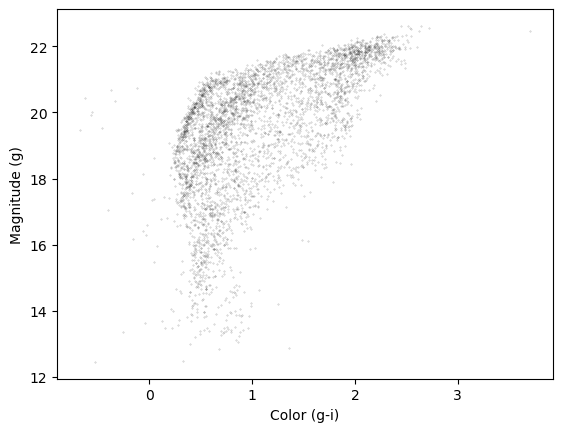

In [41]:
x = candidate_df['g_mean_psf_mag'] - candidate_df['i_mean_psf_mag']
y = candidate_df['g_mean_psf_mag']
plt.plot(x, y, 'ko', markersize=0.3, alpha=0.3)

plt.ylabel('Magnitude (g)')
plt.xlabel('Color (g-i)')

Need to invert y axis (stupid magnitude scale) and zero in on the main sequence color

(22.0, 14.0)

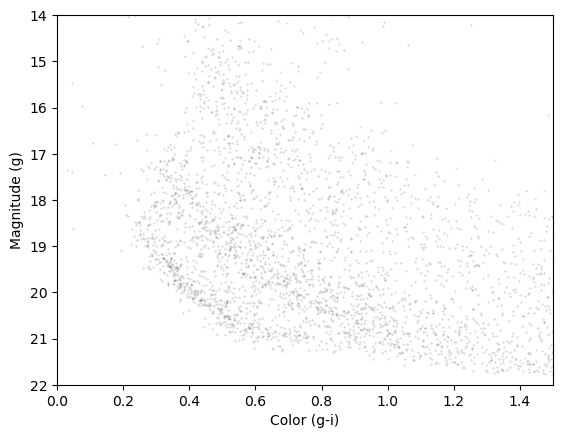

In [42]:
x = candidate_df['g_mean_psf_mag'] - candidate_df['i_mean_psf_mag']
y = candidate_df['g_mean_psf_mag']
plt.plot(x, y, 'ko', markersize=0.3, alpha=0.3)

plt.ylabel('Magnitude (g)')
plt.xlabel('Color (g-i)')

plt.xlim([0, 1.5])
plt.ylim([22, 14])

GD-1 is the over dense region in lower left

Let's make a function so we can do this again

In [43]:
def plot_cmd(dataframe):
    """Plot a color magnitude diagram.
    
    dataframe: DataFrame or Table with photometry data
    """
    y = dataframe['g_mean_psf_mag']
    x = dataframe['g_mean_psf_mag'] - dataframe['i_mean_psf_mag']

    plt.plot(x, y, 'ko', markersize=0.3, alpha=0.3)

    plt.xlim([0, 1.5])
    plt.ylim([22, 14])

    plt.ylabel('Magnitude (g)')
    plt.xlabel('Color (g-i)')

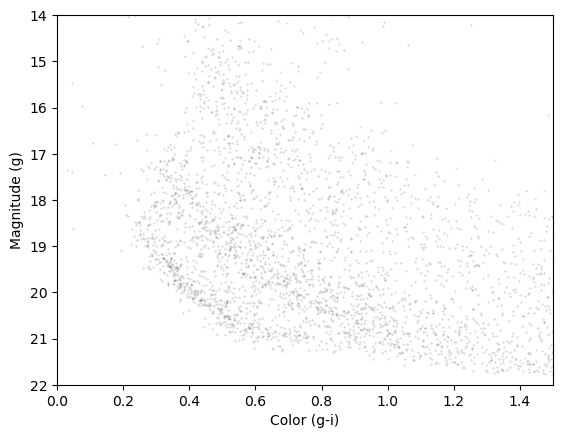

In [44]:
plot_cmd(candidate_df)

## Isochrone

From MESA MIST tracks

In [45]:
filename = 'gd1_isochrone.hdf5'
iso_df = pd.read_hdf(filename, 'iso_df')
iso_df.head()

,mag_g,color_g_i
0,28.294743,2.195021
1,28.189718,2.166076
2,28.051761,2.129312
3,27.916194,2.093721
4,27.780024,2.058585


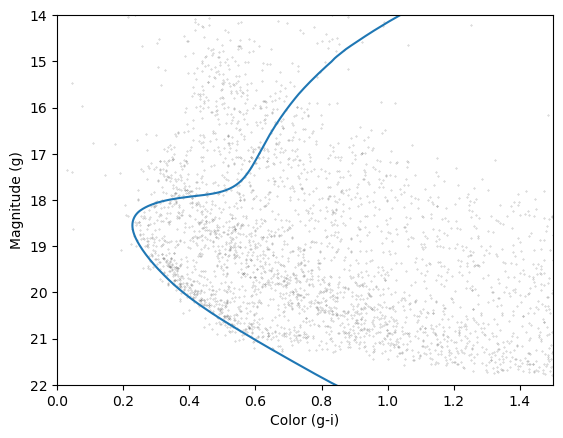

In [46]:
plot_cmd(candidate_df)
plt.plot(iso_df['color_g_i'], iso_df['mag_g']);

Although some stars have evolved off the main sequence - the main sequence is the highest desntiy and pureset sample - so we will select stars only on the main sequence

## Making a polygon

start by selecting points from the isochrone with g magnitude between 21.5 and 18 (corresponding to the main sequence)

In [47]:
g_all = iso_df['mag_g']

g_mask = (g_all > 18.0) & (g_all < 21.5)
g_mask.sum()

np.int64(117)

create a dataframe with just these rows using the mask

In [48]:
iso_masked = iso_df[g_mask]
iso_masked.head()

,mag_g,color_g_i
94,21.411746,0.692171
95,21.322466,0.670238
96,21.233380,0.648449
97,21.144427,0.626924
98,21.054549,0.605461


Move the isochrone to the left and right in color to create a polygon

In [49]:
g = iso_masked['mag_g']
left_color = iso_masked['color_g_i'] - 0.06
right_color = iso_masked['color_g_i'] + 0.12

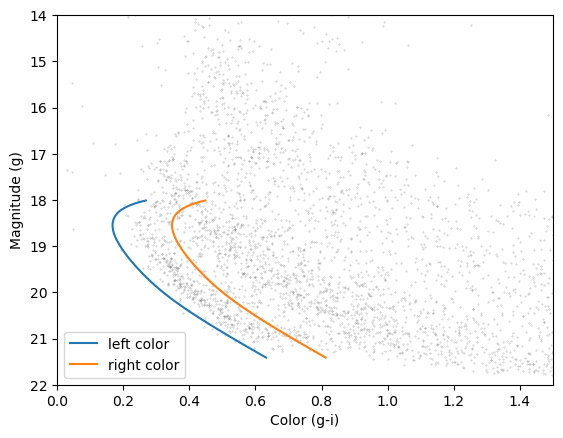

In [50]:
plot_cmd(candidate_df)

plt.plot(left_color, g, label='left color')
plt.plot(right_color, g, label='right color')

plt.legend();

## Which points are in the polygon?

Matplotlib has a function that allows us to check which points in a shape and which are outside

First need to define the polygon - want a continous shape - so reverse right color with slicing [start:stop:step]. Step by -1

In [52]:
reverse_right_color = right_color[::-1]

now we can create a loop with our two color lines

In [53]:
import numpy as np
color_loop = np.append(left_color, reverse_right_color)
color_loop.shape

(234,)

repeat for y values (g mag)

In [55]:
mag_loop = np.append(g, g[::-1])
mag_loop.shape

(234,)

plot the loop

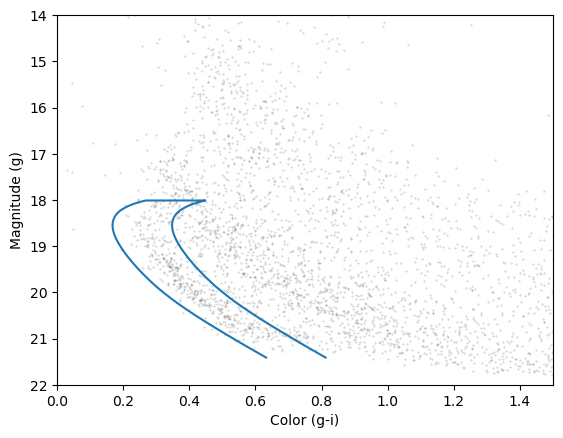

In [56]:
plot_cmd(candidate_df)
plt.plot(color_loop, mag_loop);

Polygon expects an Nx2 array. The easiest way for us to do that is to create a pandas dataframe (this also allows us to easily save this)

In [58]:
loop_df = pd.DataFrame()
loop_df['color_loop'] = color_loop
loop_df['mag_loop'] = mag_loop
loop_df.head()

,color_loop,mag_loop
0,0.632171,21.411746
1,0.610238,21.322466
2,0.588449,21.233380
3,0.566924,21.144427
4,0.545461,21.054549


Now we can pass loop_df to matplotlib's Polygon

In [59]:
from matplotlib.patches import Polygon

polygon = Polygon(loop_df)
polygon

Polygon has a `contains_points` function which checks if a point is inside the polygon. call with `polygon.contains_points(list of points)` where a point is a tuple (x,y)

## EXERCISE (5 MINUTES)
When we encounter a new object, it is good to create a toy example to test that it does what we think it does. Define a list of two points (represented as two tuples), one that should be inside the polygon and one that should be outside the polygon. Call contains_points on the polygon we just created, passing it the list of points you defined, to verify that the results are as expected.

In [60]:
## Solution
test_points = [(0.4, 20), 
           (0.4, 16)]

test_inside_mask = polygon.contains_points(test_points)
test_inside_mask

array([ True, False])

## Save the Polygon

Let's save the polygon for reproducibility

In [61]:
filename = 'gd1_data.hdf'
loop_df.to_hdf(filename, key='loop_df')

## Selecting based on photometry

We need to create our list of points from our candidate_df `g_mean_psf_mag` and `g-i` color. Once again, and pandas data frame will be sufficient

In [62]:
cmd_df = pd.DataFrame()

cmd_df['color'] = candidate_df['g_mean_psf_mag'] - candidate_df['i_mean_psf_mag']
cmd_df['mag'] = candidate_df['g_mean_psf_mag']

cmd_df.head()

,color,mag
0,0.388201,17.706100
1,1.168701,20.274401
2,1.086599,19.254900
3,0.360802,19.446501
4,2.060799,22.069599


In [63]:
inside_mask = polygon.contains_points(cmd_df)
inside_mask

array([False, False, False, ..., False, False, False], shape=(4300,))

## EXERCISE (5 MINUTES)
Boolean values are stored as 0s and 1s. FALSE = 0 and TRUE = 1. Use this information to determine the number of stars that fall inside the polygon.

In [64]:
# Solution
inside_mask.sum()

np.int64(486)

In [65]:
winner_df = candidate_df[inside_mask]

create a CMD and high-light the stars on the GD-1 main sequence in green. 

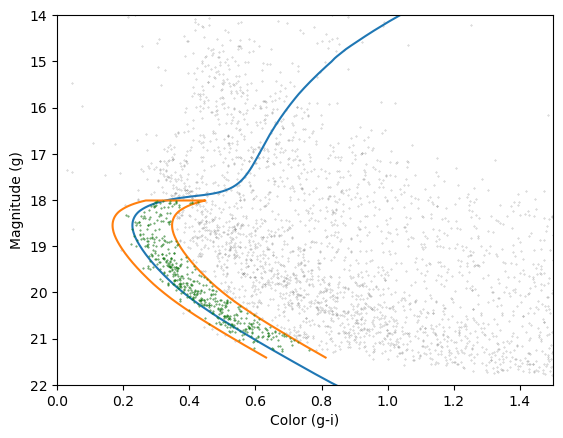

In [66]:
plot_cmd(candidate_df)
plt.plot(iso_df['color_g_i'], iso_df['mag_g'])
plt.plot(color_loop, mag_loop)

x = winner_df['g_mean_psf_mag'] - winner_df['i_mean_psf_mag']
y = winner_df['g_mean_psf_mag']
plt.plot(x, y, 'go', markersize=0.5, alpha=0.5);

Now if we plot the stars we selected with both our Gaia ra, dec, proper motion, and our PanSTARRs isochrone we can clearly see GD1

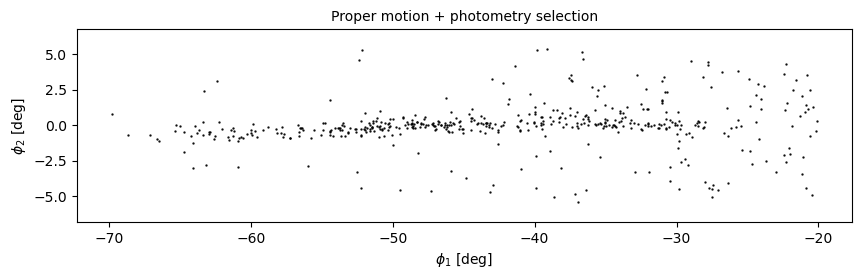

In [67]:
fig = plt.figure(figsize=(10,2.5))

x = winner_df['phi1']
y = winner_df['phi2']
plt.plot(x, y, 'ko', markersize=0.7, alpha=0.9)

plt.xlabel(r'$\phi_1$ [deg]')
plt.ylabel(r'$\phi_2$ [deg]')
plt.title('Proper motion + photometry selection', fontsize='medium')

plt.axis('equal');

This is our first use of `figure` and `figsize`

We also are using the Latex rendering in Matplotlib (note that you need the r in front of the string and the $ for math mode

This is the final plot we want to make - so let's put it in a function

In [68]:
def plot_cmd_selection(df):
    x = df['phi1']
    y = df['phi2']

    plt.plot(x, y, 'ko', markersize=0.7, alpha=0.9)

    plt.xlabel(r'$\phi_1$ [deg]')
    plt.ylabel(r'$\phi_2$ [deg]')
    plt.title('Proper motion + photometry selection', fontsize='medium')

    plt.axis('equal')

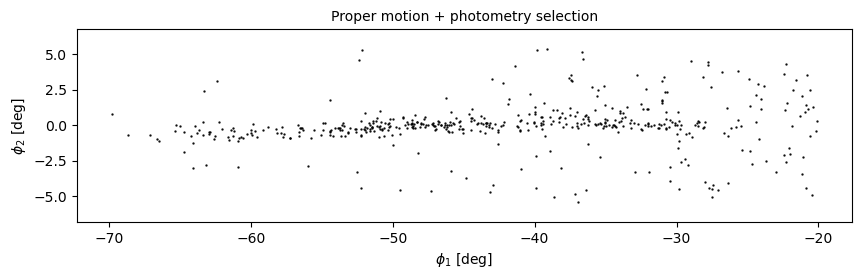

In [69]:
fig = plt.figure(figsize=(10,2.5))
plot_cmd_selection(winner_df)

This is our final dataset - we should save it

In [70]:
filename = 'gd1_data.hdf'
winner_df.to_hdf(filename, key='winner_df')

In [71]:
MB = 1024 * 1024
getsize(filename) / MB

1.4948883056640625

### Summary
* matplotlib is not just for figures - contains useful geometric entities like points and polygons
* create figure and control aspect ratio
* save every element of data analysis pipeline that would be needed to replicate results later

# Visualization
* What elements make a compelling and clear visualization?
* what tools and techniques are available to save time creating presentation and publication read figures?

## Making a figure that Tells a Story

What makes a figure professional looking? What communicates scientific results clearly?

Review Fig 1

## EXERCISE (10 MINUTES)
Think about the following questions:

What is the primary scientific result of this work?

What story is this figure telling?

In the design of this figure, can you identify 1 or 2 choices the authors made that you think are effective? Think about big-picture elements, like the number of panels and how they are arranged, as well as details like the choice of typeface.

Can you identify 1 or 2 elements that could be improved, or that you might have done differently?

## Solution
* primary result of selection criteria making a cleaner selection of GD-1 is clear
* documents the selection process
* mostly black and white, color used effectively, fonts are large. Good for screen and print, good start fo those with low vision or poor color vision
* annotations used effectively to guide reader
* panels grouped together for consistent units, dimensions, axes
* on sky positions do not need so much white space
* axes ticks for on-sky position not needed - use a size bar
* text annotations could be darker
* legend in bottom right pane is too small for low-vision readers. Details should be included in caption

# Plotting GD-1 with Annotations

Annotations use three features to present results more clearly:
* vertical dashed line
* label to ID new region
* annotate features with arrow

# EXERCISE (20 MINUTES)
Plot the selected stars in winner_df using the plot_cmd_selection function and then choose any or all of these features and add them to the figure:

To draw vertical lines, see plt.vlines and plt.axvline.

To add text, see plt.text.

To add an annotation with text and an arrow, see plt.annotate.

Here is some additional information about text and arrows. https://matplotlib.org/stable/tutorials/text/annotations.html

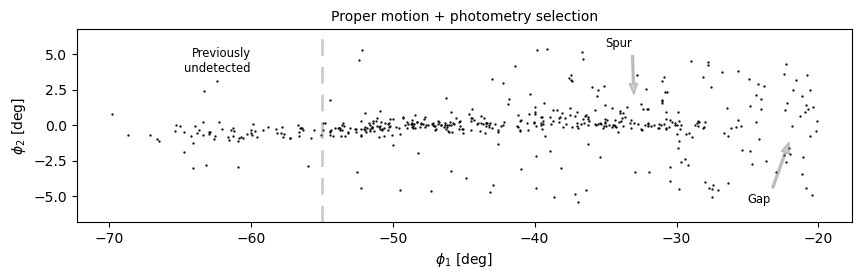

In [73]:
#Solution
fig = plt.figure(figsize=(10,2.5))
plot_cmd_selection(winner_df)
plt.axvline(-55, ls='--', color='gray', 
            alpha=0.4, dashes=(6,4), lw=2)
plt.text(-60, 5.5, 'Previously\nundetected', 
         fontsize='small', ha='right', va='top')

arrowprops=dict(color='gray', shrink=0.05, width=1.5, 
                headwidth=6, headlength=8, alpha=0.4)

plt.annotate('Spur', xy=(-33, 2), xytext=(-35, 5.5),
             arrowprops=arrowprops,
             fontsize='small')

plt.annotate('Gap', xy=(-22, -1), xytext=(-25, -5.5),
             arrowprops=arrowprops,
             fontsize='small');

## Customization

levels of customization:
* current figure (e.g. tick_params)
* all figures in a notebook with rcParams
* override more than a few defaults with style sheets

When you customize consider accessibility. AAS guide:  https://journals.aas.org/graphics-guide/

So far, everything has been in `plt` but you may want to modify an object. We are going to create a subplot object. Note subplots and axes appear to be very similar and are often used interchangably because a subplot is an axes object with additional attributes

Use `fig.add_subplot(ncols, nrows, plotnum)`

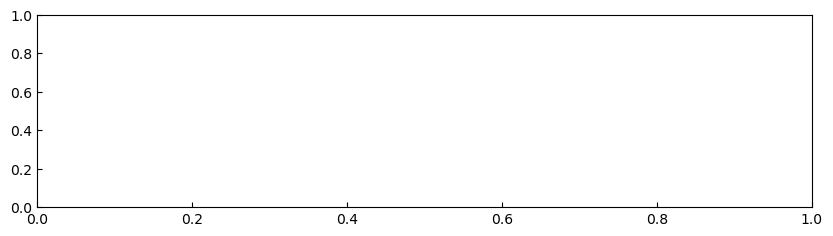

In [76]:
fig = plt.figure(figsize=(10,2.5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(direction='in')

## EXERCISE (5 MINUTES)
Read the documentation of tick_params and use it to put ticks on the top and right sides of the axes.

https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.tick_params.html

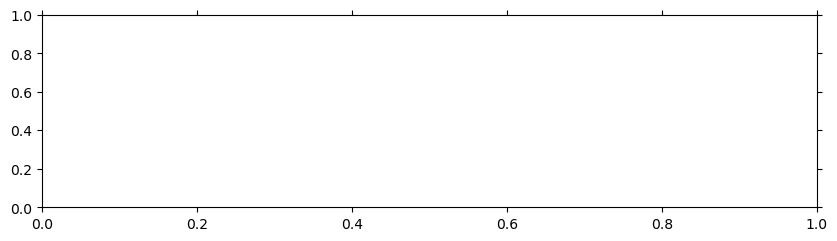

In [77]:
# Solution
fig = plt.figure(figsize=(10,2.5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, right=True)

## rcParams

make a change for whole notebook

rcParams is a dictionary with defaults created when you import matplotlib

In [78]:
plt.rcParams['font.size']

10.0

set to a new value

In [79]:
plt.rcParams['font.size'] = 14

## EXERCISE (5 MINUTES)
Plot the previous figure again, and see what font sizes have changed. Look up any other element of rcParams, change its value, and check the effect on the figure.

black


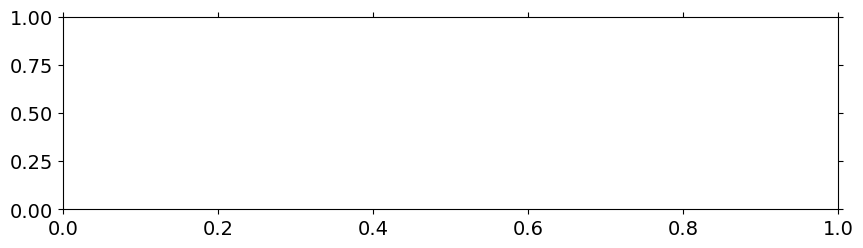

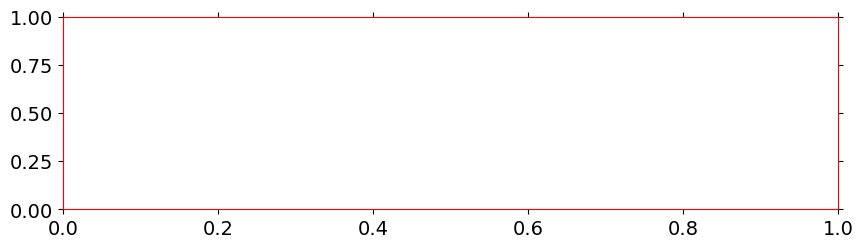

In [80]:
# Solution
fig = plt.figure(figsize=(10,2.5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, right=True)

# Looking up the 'axes.edgecolor' rcParams value
print(plt.rcParams['axes.edgecolor'])

plt.rcParams['axes.edgecolor'] = 'red'

fig = plt.figure(figsize=(10,2.5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, right=True)

# changing the rcParams value back to its original value
plt.rcParams['axes.edgecolor'] = 'black'

rcParams from a matplotlibrc file. To find the file

In [81]:
import matplotlib as mpl
mpl.matplotlib_fname()

'/Users/bostroem/.matplotlib/matplotlibrc'

if the file doesn't exist - you can save this to ~/.matplotlib/matplotlibrc

https://matplotlib.org/stable/users/explain/customizing.html

# Style Sheets

changes you want to be able to make over and over again

almost like multiple matplotlibrc files

style sheet reference: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html

list available

In [83]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'az-paper-onecol',
 'az-paper-twocol',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

note seaborn-paper, seaborn-talk, and seaborn-poster have defaults for all of these situations

You can use a style sheet like this

In [84]:
plt.style.use('fivethirtyeight')

return to default

In [85]:
plt.style.use('default')

## EXERCISE (5 MINUTES)
Choose one of the styles on the list and select it by calling use. Then go back and plot one of the previous figures to see what changes in the figure’s appearance.

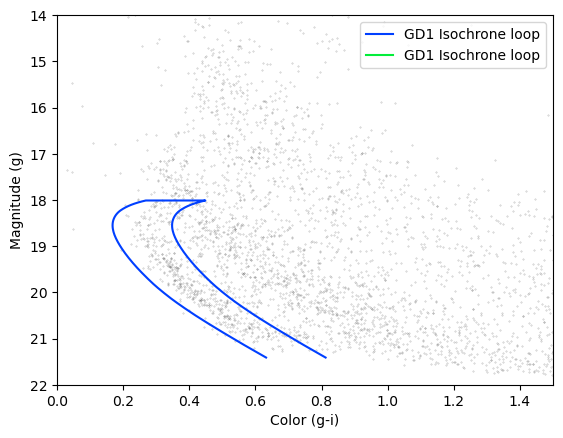

In [87]:
plt.style.use('seaborn-v0_8-bright')

plot_cmd(candidate_df)
plt.plot(loop_df['color_loop'], loop_df['mag_loop'], g, label='GD1 Isochrone loop')

plt.legend();

You can also make your own style sheet. I have included one I use for my paper figures

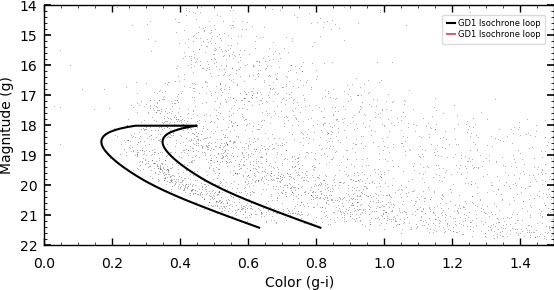

In [88]:
plt.style.use('./az-paper-twocol.mplstyle')

plot_cmd(candidate_df)

plt.plot(loop_df['color_loop'], loop_df['mag_loop'], g, label='GD1 Isochrone loop')

plt.legend();

The prefix ./ tells Matplotlib to look for the file in the current directory.  
Alternately put style sheets in stylelib/ in your configuration directory. To find your configuration directory

In [89]:
mpl.get_configdir()

'/Users/bostroem/.matplotlib'

## Multiple Panels

add subplot creates equal size panels. use subplot2grid to create unequal. subplot2grid takes a shape (nrow, ncol) (tuple and a location (also a tuple (row, col)))

equal size panels

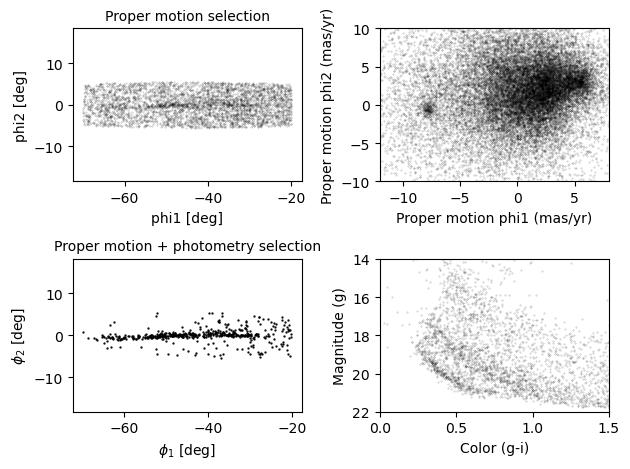

In [94]:
shape = (2, 2) #nrow, ncol

plt.style.use('default')

fig = plt.figure()
ax1 = plt.subplot2grid(shape, (0, 0))
plot_pm_selection(candidate_df)

ax2 = plt.subplot2grid(shape, (0, 1))
plot_proper_motion(centerline_df)

ax3 = plt.subplot2grid(shape, (1, 0))
plot_cmd_selection(winner_df)

ax4 = plt.subplot2grid(shape, (1, 1))
plot_cmd(candidate_df)

plt.tight_layout()

plt.tight_layout cleans things up

## EXERCISE (5 MINUTES)
What happens if you leave out tight_layout?

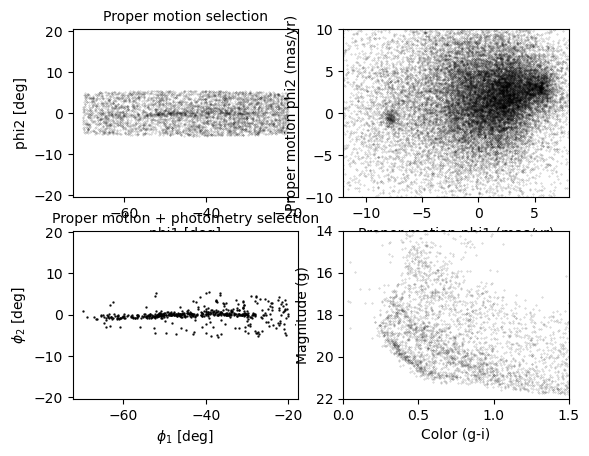

In [95]:
shape = (2, 2) #nrow, ncol

plt.style.use('default')

fig = plt.figure()
ax1 = plt.subplot2grid(shape, (0, 0))
plot_pm_selection(candidate_df)

ax2 = plt.subplot2grid(shape, (0, 1))
plot_proper_motion(centerline_df)

ax3 = plt.subplot2grid(shape, (1, 0))
plot_cmd_selection(winner_df)

ax4 = plt.subplot2grid(shape, (1, 1))
plot_cmd(candidate_df)


## Adjusting propotions

Make the shape bigger and then have one panel span multiple columns (or rows) with colspan (rowspan)

* change figsize  
* change shape  
* locations also have to reflect colspan

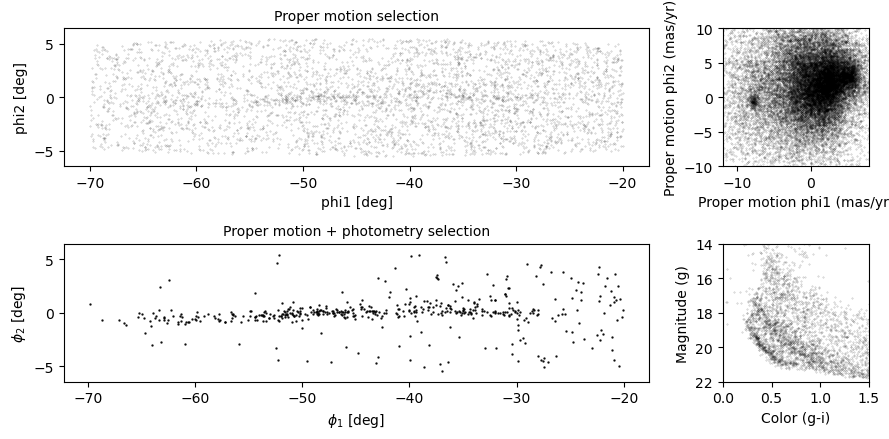

In [96]:
shape = (2, 4)

plt.figure(figsize=(9, 4.5))

ax1 = plt.subplot2grid(shape, (0, 0), colspan=3)
plot_pm_selection(candidate_df)

ax2 = plt.subplot2grid(shape, (0, 3))
plot_proper_motion(centerline_df)

ax3 = plt.subplot2grid(shape, (1, 0), colspan=3)
plot_cmd_selection(winner_df)

ax4 = plt.subplot2grid(shape, (1, 3))
plot_cmd(candidate_df)

plt.tight_layout()

## EXERCISE (5 MINUTES)
In this example, the ratio of the widths of the panels is 3:1. How would you adjust it if you wanted the ratio to be 3:2?

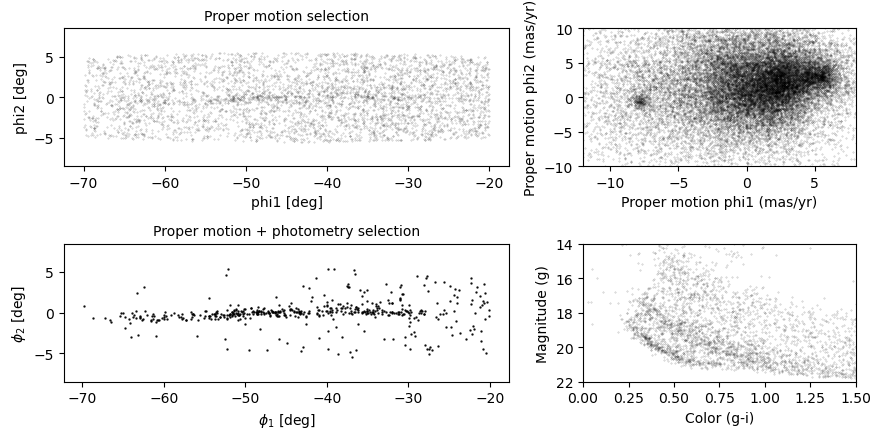

In [98]:
#Solution
shape = (2, 5)                                   # CHANGED


plt.figure(figsize=(9, 4.5))

ax1 = plt.subplot2grid(shape, (0, 0), colspan=3)
plot_pm_selection(candidate_df)

ax2 = plt.subplot2grid(shape, (0, 3), colspan=2)       # CHANGED
plot_proper_motion(centerline_df)

ax3 = plt.subplot2grid(shape, (1, 0), colspan=3)
plot_cmd_selection(winner_df)

ax4 = plt.subplot2grid(shape, (1, 3), colspan=2)       # CHANGED
plot_cmd(candidate_df)

plt.tight_layout()

## Adding the shaded regions

we defined pm1_rect and pm2_rect in episode 4. Now we need to put them into a polygon. We used Pandas before - he is another option using np.transpose

In [99]:
vertices = np.transpose([pm1_rect, pm2_rect])
vertices

array([[-8.9, -2.2],
       [-8.9,  1. ],
       [-6.9,  1. ],
       [-6.9, -2.2],
       [-8.9, -2.2]])

In [103]:
#ONLY IF SOMEONE ASKS
vertices_df = pd.DataFrame()
vertices_df['pm1_rect'] = pm1_rect
vertices_df['pm2_rect'] = pm2_rect

poly = Polygon(vertices_df, closed=True, 
                   facecolor='orange', alpha=0.4)

Build a ploygon. Add closed=True, color, and alpha

In [104]:
poly = Polygon(vertices, closed=True, 
                   facecolor='orange', alpha=0.4)

use `add_patch` which acts on an axis object - so create the subplot first. You have to create the polygon each time you add it

(-10.0, 10.0)

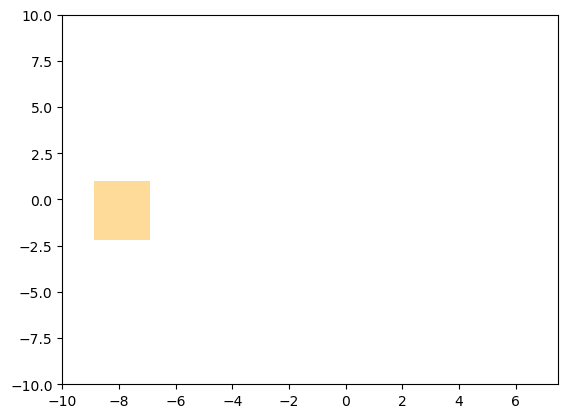

In [107]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
poly = Polygon(vertices, closed=True, 
                   facecolor='orange', alpha=0.4)
ax.add_patch(poly)
ax.set_xlim(-10, 7.5)
ax.set_ylim(-10, 10)

Add proper motion behind it

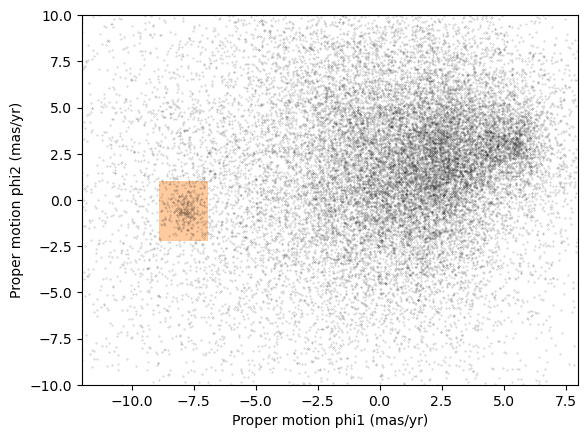

In [106]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
plot_proper_motion(centerline_df)
poly = Polygon(vertices, closed=True, 
               facecolor='C1', alpha=0.4)
ax.add_patch(poly)

##  EXERCISE (5 MINUTES)
Add a few lines to be run after the plot_cmd function to show the polygon we selected as a shaded area.

Hint: pass loop_df as an argument to Polygon as we did in episode 7 and then plot it using add_patch.

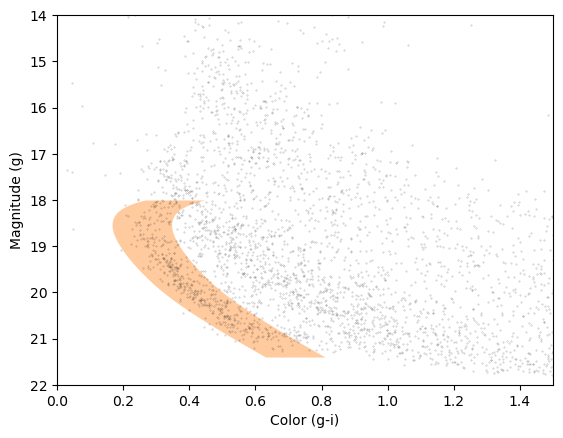

In [108]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
plot_cmd(candidate_df)
poly_cmd = Polygon(loop_df, closed=True, 
              facecolor='C1', alpha=0.4)
ax.add_patch(poly_cmd)

## EXERCISE (5 MINUTES)
Add the Polygon patches you just created to the right panels of the four panel figure.

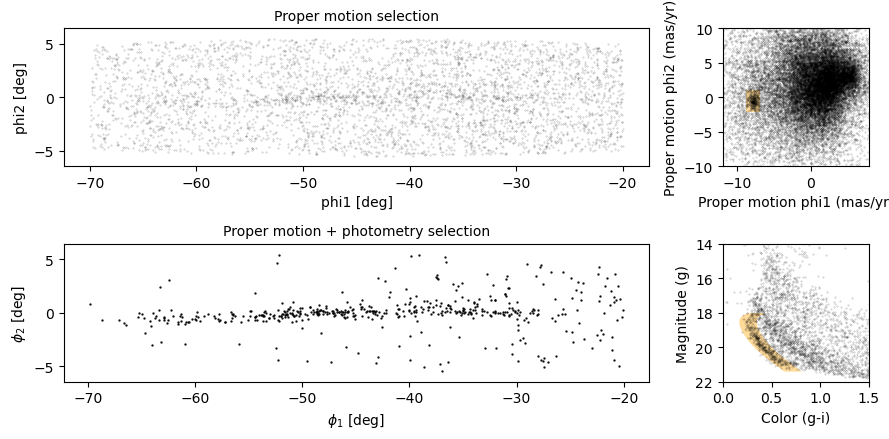

In [109]:
fig = plt.figure(figsize=(9, 4.5))

shape = (2, 4)
ax1 = plt.subplot2grid(shape, (0, 0), colspan=3)
plot_pm_selection(candidate_df)

ax2 = plt.subplot2grid(shape, (0, 3))
plot_proper_motion(centerline_df)
poly = Polygon(vertices, closed=True,
               facecolor='orange', alpha=0.4)
ax2.add_patch(poly)

ax3 = plt.subplot2grid(shape, (1, 0), colspan=3)
plot_cmd_selection(winner_df)

ax4 = plt.subplot2grid(shape, (1, 3))
plot_cmd(candidate_df)
poly_cmd = Polygon(loop_df, closed=True, 
               facecolor='orange', alpha=0.4)
ax4.add_patch(poly_cmd)

plt.tight_layout()

Key points:
* Effective figures focus on telling a single story clearly and authentically.
* can sketch this without a computer
* annotations to guide reader
* matplotlib styles
* use custom styles if you find yourself repeating the same style over and over